# IMPLEMENTASI ALGORITMA DECISION TREE UNTUK PREDIKSI RISIKO STROKE

### Mata Kuliah
**Data Mining**

### Disusun Oleh
Nama :

*   Ferly Ardiansyah (312310448)
*   Bayu Aji Yuwono (312310492)
*   Wawan suwandi (312310457)


### Algoritma
Decision Tree

### Dataset
Healthcare Stroke Prediction Dataset

### Tools
Google Colaboratory (Python)

---

## Deskripsi

Pada notebook ini dilakukan implementasi algoritma **Decision Tree** untuk memprediksi kemungkinan seorang pasien mengalami stroke berdasarkan karakteristik kesehatan yang dimiliki.

Proses implementasi meliputi:

- Import library
- Membaca dataset
- Inspeksi dataset
- Exploratory Data Analysis (EDA)
- Preprocessing data
- Pembangunan model Decision Tree
- Evaluasi model
- Interpretasi hasil
- Kesimpulan

# A. Import Library

Tahap pertama adalah mengimpor seluruh library yang dibutuhkan selama proses analisis data, visualisasi, preprocessing, pembangunan model Decision Tree, hingga evaluasi model.

Library yang digunakan meliputi:

- **Pandas** → Mengolah dataset
- **NumPy** → Operasi numerik
- **Matplotlib & Seaborn** → Visualisasi data
- **Scikit-Learn** → Machine Learning
- **Google Colab Files** → Upload dataset

In [ ]:
# ==========================================================
# A. IMPORT LIBRARY
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

print("=" * 60)
print("SELURUH LIBRARY BERHASIL DIIMPORT")
print("=" * 60)

SELURUH LIBRARY BERHASIL DIIMPORT


# B. Membaca Dataset

Tahap berikutnya adalah mengunggah dan membaca dataset ke dalam Google Colab menggunakan library **Pandas**.

Dataset yang digunakan adalah **Healthcare Stroke Prediction Dataset** yang berisi data pasien beserta informasi kesehatan yang akan digunakan sebagai dasar dalam proses klasifikasi menggunakan algoritma Decision Tree.

Dataset terdiri atas beberapa atribut seperti:

- Gender
- Age
- Hypertension
- Heart Disease
- Ever Married
- Work Type
- Residence Type
- Average Glucose Level
- BMI
- Smoking Status
- Stroke (Target)

In [ ]:
# ==========================================================
# B. MEMBACA DATASET
# ==========================================================

# Membaca dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

print("=" * 60)
print("DATASET BERHASIL DIMUAT")
print("=" * 60)

print(f"Jumlah Baris : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

print("\nInformasi 5 Data Pertama")
display(df.head())

DATASET BERHASIL DIMUAT
Jumlah Baris : 5110
Jumlah Kolom : 12

Informasi 5 Data Pertama


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Interpretasi

Dataset berhasil dibaca menggunakan library **Pandas** dan disimpan ke dalam DataFrame dengan nama **df**. Berdasarkan hasil pembacaan, dataset terdiri dari **5.110 baris** dan **12 kolom** yang merepresentasikan karakteristik pasien beserta status stroke sebagai variabel target.

Selanjutnya, lima data pertama ditampilkan menggunakan fungsi `head()` untuk memberikan gambaran awal mengenai struktur dataset sebelum dilakukan proses inspeksi, eksplorasi data (EDA), dan preprocessing.

# C. Inspeksi Dataset

Tahap inspeksi dataset dilakukan untuk memahami struktur dan karakteristik data sebelum proses analisis lebih lanjut. Pemeriksaan meliputi informasi dataset, statistik deskriptif, jumlah nilai yang hilang (*missing value*), serta distribusi kelas target (stroke).

Hasil inspeksi ini menjadi dasar dalam menentukan tahapan preprocessing yang akan dilakukan pada dataset.

In [ ]:
# ==========================================================
# C. INSPEKSI DATASET
# ==========================================================

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)

# Informasi dataset
print("\n1. Informasi Dataset")
df.info()

# Statistik deskriptif
print("\n" + "=" * 60)
print("2. Statistik Deskriptif")
print("=" * 60)
display(df.describe())

# Missing value
print("\n" + "=" * 60)
print("3. Jumlah Missing Value")
print("=" * 60)
display(df.isnull().sum())

# Distribusi kelas target
print("\n" + "=" * 60)
print("4. Distribusi Kelas Target")
print("=" * 60)
display(df["stroke"].value_counts())

INFORMASI DATASET

1. Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

2. Statistik Deskriptif


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000



3. Jumlah Missing Value


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201



4. Distribusi Kelas Target


,count
stroke,
0,4861
1,249


### Interpretasi

Berdasarkan hasil inspeksi dataset, diperoleh beberapa informasi penting sebagai berikut.

1. Dataset terdiri dari **5.110 baris** dan **12 atribut**, yang terdiri atas data numerik dan kategorikal.

2. Hasil pemeriksaan menunjukkan bahwa hanya kolom **BMI** yang memiliki nilai kosong (*missing value*). Oleh karena itu, pada tahap preprocessing akan dilakukan pengisian nilai yang hilang menggunakan metode **Median Imputation** agar distribusi data tetap representatif.

3. Statistik deskriptif memberikan gambaran mengenai nilai minimum, maksimum, rata-rata, serta persebaran data pada setiap atribut numerik, seperti usia (*age*), kadar glukosa rata-rata (*avg_glucose_level*), dan BMI.

4. Distribusi kelas target menunjukkan bahwa jumlah pasien **tidak mengalami stroke** jauh lebih banyak dibandingkan pasien yang mengalami stroke. Hal ini mengindikasikan bahwa dataset bersifat **imbalanced**, sehingga pada tahap pembangunan model akan digunakan parameter **class_weight='balanced'** agar model mampu mengenali kelas minoritas dengan lebih baik.

# D. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum dilakukan proses preprocessing. Pada tahap ini dilakukan beberapa visualisasi untuk mengetahui distribusi data, keseimbangan kelas target, serta pola yang terdapat pada dataset.

## 1. Distribusi Pasien Stroke

Visualisasi ini bertujuan untuk mengetahui perbandingan jumlah pasien yang mengalami stroke dan tidak mengalami stroke pada dataset.

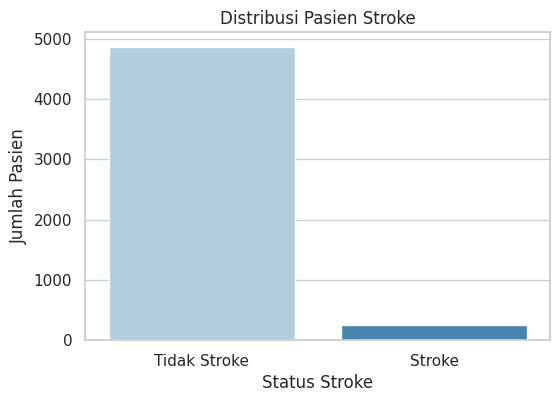

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="stroke",
    hue="stroke",
    palette="Blues",
    legend=False
)

plt.title("Distribusi Pasien Stroke")
plt.xlabel("Status Stroke")
plt.ylabel("Jumlah Pasien")
plt.xticks([0,1],["Tidak Stroke","Stroke"])

plt.show()

### Interpretasi

Grafik menunjukkan bahwa jumlah pasien **tidak mengalami stroke** jauh lebih banyak dibandingkan pasien yang mengalami stroke.

Hal ini menunjukkan bahwa dataset memiliki distribusi kelas yang tidak seimbang (*imbalanced dataset*). Oleh karena itu, pada tahap pembangunan model digunakan parameter **class_weight='balanced'** agar model mampu mengenali kelas minoritas dengan lebih baik.

## 2. Distribusi Usia Pasien

Visualisasi ini digunakan untuk melihat penyebaran usia pasien pada dataset sehingga dapat diketahui karakteristik umur responden.

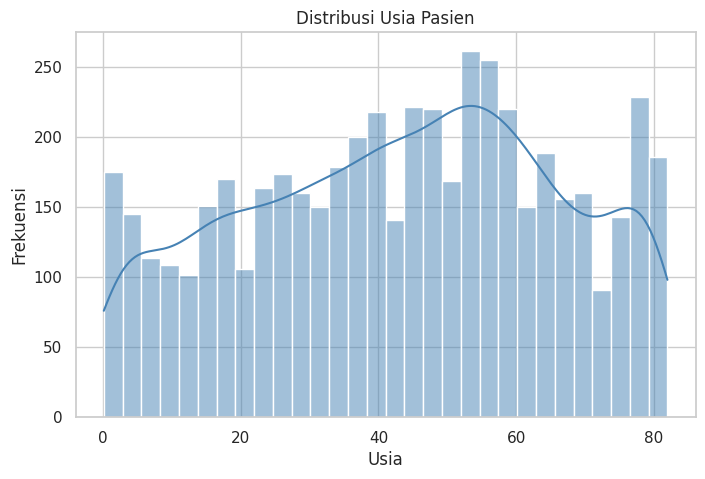

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribusi Usia Pasien")
plt.xlabel("Usia")
plt.ylabel("Frekuensi")

plt.show()

### Interpretasi

Distribusi usia menunjukkan bahwa sebagian besar pasien berada pada kelompok usia dewasa hingga lanjut usia.

Hal ini mengindikasikan bahwa usia berpotensi menjadi salah satu faktor penting dalam menentukan risiko stroke.

## 3. Distribusi Body Mass Index (BMI)

Visualisasi ini bertujuan untuk melihat penyebaran nilai BMI serta mengetahui apakah terdapat pola distribusi yang tidak normal.

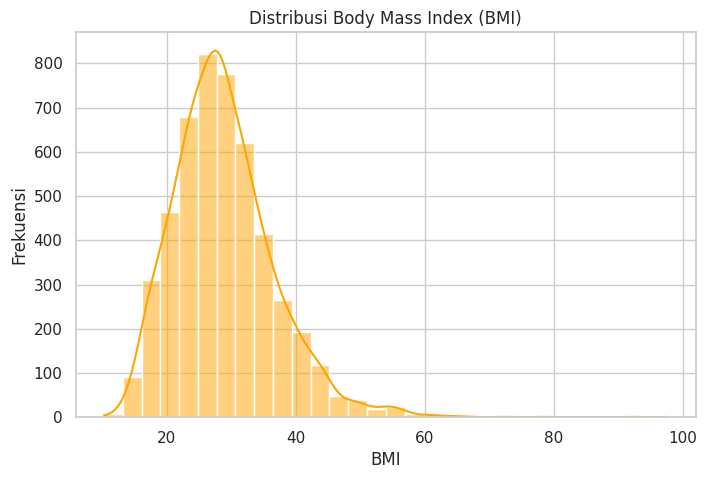

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="bmi",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribusi Body Mass Index (BMI)")
plt.xlabel("BMI")
plt.ylabel("Frekuensi")

plt.show()

### Interpretasi

Distribusi BMI menunjukkan adanya penyebaran data yang tidak sepenuhnya simetris. Selain itu masih terdapat beberapa nilai yang hilang (*missing value*) pada atribut BMI.

Berdasarkan kondisi tersebut, pada tahap preprocessing digunakan metode **Median Imputation** karena median lebih tahan terhadap pengaruh nilai ekstrem (*outlier*) dibandingkan rata-rata (*mean*).

## 4. Boxplot BMI

Boxplot digunakan untuk mengidentifikasi keberadaan nilai ekstrem (*outlier*) pada atribut BMI.

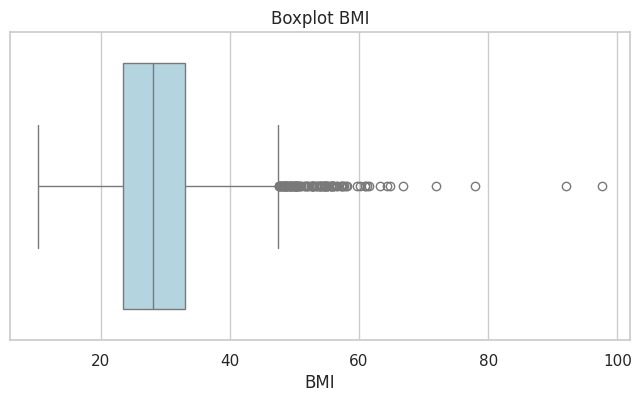

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["bmi"],
    color="lightblue"
)

plt.title("Boxplot BMI")
plt.xlabel("BMI")

plt.show()

### Interpretasi

Boxplot menunjukkan terdapat beberapa nilai BMI yang berada jauh dari sebaran utama data (*outlier*). Keberadaan outlier dapat memengaruhi nilai rata-rata sehingga penggunaan **median** sebagai metode imputasi menjadi pilihan yang lebih tepat.

## 5. Heatmap Korelasi

Heatmap digunakan untuk melihat hubungan antar variabel numerik pada dataset.

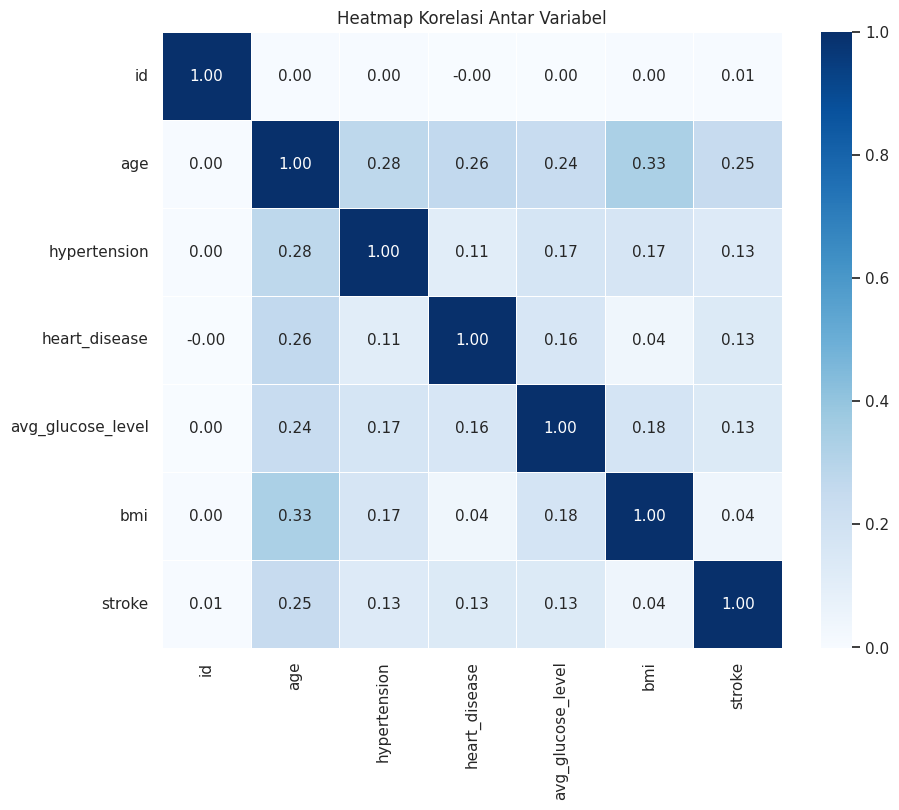

In [ ]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antar Variabel")

plt.show()

### Interpretasi

Heatmap menunjukkan tingkat hubungan antar variabel numerik. Nilai korelasi yang mendekati **1** menunjukkan hubungan positif yang kuat, sedangkan nilai yang mendekati **0** menunjukkan hubungan yang lemah.

Visualisasi ini membantu memahami karakteristik dataset sebelum dilakukan proses preprocessing dan pembangunan model Decision Tree.

# E. Preprocessing Data

Preprocessing merupakan tahap persiapan data sebelum digunakan dalam proses pelatihan model Machine Learning. Tahap ini bertujuan untuk meningkatkan kualitas dataset sehingga dapat diproses dengan baik oleh algoritma Decision Tree.

Pada penelitian ini dilakukan tiga tahapan preprocessing, yaitu:

1. Menghapus kolom **id** karena hanya berfungsi sebagai identitas unik setiap pasien.
2. Mengatasi nilai yang hilang (*missing value*) pada atribut **BMI** menggunakan metode **Median Imputation**.
3. Mengubah seluruh atribut kategorikal menjadi data numerik menggunakan **Label Encoding** agar dapat diproses oleh algoritma Decision Tree.

In [ ]:
# ==========================================================
# E. PREPROCESSING DATA
# ==========================================================

print("=" * 60)
print("PREPROCESSING DATA")
print("=" * 60)

# ----------------------------------------------------------
# 1. Menghapus Kolom ID
# ----------------------------------------------------------
if "id" in df.columns:
    df.drop(columns=["id"], inplace=True)
    print("✓ Kolom 'id' berhasil dihapus.")
else:
    print("✓ Kolom 'id' sudah tidak ada.")

# ----------------------------------------------------------
# 2. Mengatasi Missing Value pada BMI
# ----------------------------------------------------------
imputer = SimpleImputer(strategy="median")

df["bmi"] = imputer.fit_transform(df[["bmi"]])

print("✓ Missing value pada kolom 'bmi' berhasil diisi menggunakan median.")

# ----------------------------------------------------------
# 3. Label Encoding
# ----------------------------------------------------------
label_encoder = LabelEncoder()

categorical_columns = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

print("✓ Seluruh atribut kategorikal berhasil diubah menjadi numerik.")

# ----------------------------------------------------------
# Hasil Preprocessing
# ----------------------------------------------------------
print("\nJumlah Missing Value Setelah Preprocessing")
display(df.isnull().sum())

print("\n5 Data Pertama Setelah Preprocessing")
display(df.head())

PREPROCESSING DATA
✓ Kolom 'id' berhasil dihapus.
✓ Missing value pada kolom 'bmi' berhasil diisi menggunakan median.
✓ Seluruh atribut kategorikal berhasil diubah menjadi numerik.

Jumlah Missing Value Setelah Preprocessing


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0



5 Data Pertama Setelah Preprocessing


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


### Interpretasi

Tahap preprocessing telah berhasil dilakukan sehingga dataset siap digunakan pada proses pembagian data (*train-test split*) dan pembangunan model Decision Tree.

Adapun hasil preprocessing adalah sebagai berikut:

- Kolom **id** berhasil dihapus karena tidak memiliki pengaruh terhadap proses klasifikasi.
- Seluruh nilai yang hilang pada atribut **BMI** berhasil diisi menggunakan metode **Median Imputation**. Metode ini dipilih karena berdasarkan hasil EDA terdapat beberapa nilai ekstrem (*outlier*) pada atribut BMI, sehingga median lebih representatif dibandingkan rata-rata (*mean*).
- Seluruh atribut kategorikal berhasil diubah menjadi data numerik menggunakan **Label Encoding**, sehingga seluruh fitur pada dataset telah sesuai dengan kebutuhan algoritma Decision Tree.

Setelah preprocessing selesai dilakukan, dataset tidak lagi memiliki nilai yang hilang dan seluruh data telah siap digunakan untuk proses pelatihan serta pengujian model.

# F. Pembagian Data (Train-Test Split)

Setelah proses preprocessing selesai, dataset dibagi menjadi dua bagian, yaitu **data latih (training data)** dan **data uji (testing data)**.

Pembagian data dilakukan dengan perbandingan **80% untuk data latih** dan **20% untuk data uji**. Data latih digunakan untuk membangun model Decision Tree, sedangkan data uji digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dipelajari sebelumnya.

Pada tahap ini juga dilakukan pemisahan antara **fitur (X)** dan **target (y)**. Variabel **stroke** digunakan sebagai target klasifikasi, sedangkan atribut lainnya digunakan sebagai fitur masukan model.

In [ ]:
# ==========================================================
# F. PEMBAGIAN DATA (TRAIN-TEST SPLIT)
# ==========================================================

print("=" * 60)
print("PEMBAGIAN DATA TRAINING DAN TESTING")
print("=" * 60)

# ----------------------------------------------------------
# Memisahkan Fitur (X) dan Target (y)
# ----------------------------------------------------------
X = df.drop("stroke", axis=1)
y = df["stroke"]

# ----------------------------------------------------------
# Membagi Data Training dan Testing
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ----------------------------------------------------------
# Menampilkan Hasil Pembagian Data
# ----------------------------------------------------------
print(f"Jumlah Data Keseluruhan : {len(df)}")
print(f"Jumlah Data Training    : {len(X_train)}")
print(f"Jumlah Data Testing     : {len(X_test)}")

print("\nUkuran Data Training")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nUkuran Data Testing")
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

PEMBAGIAN DATA TRAINING DAN TESTING
Jumlah Data Keseluruhan : 5110
Jumlah Data Training    : 4088
Jumlah Data Testing     : 1022

Ukuran Data Training
X_train : (4088, 10)
y_train : (4088,)

Ukuran Data Testing
X_test  : (1022, 10)
y_test  : (1022,)


### Interpretasi

Pada tahap ini, dataset berhasil dipisahkan menjadi data latih (*training data*) dan data uji (*testing data*). Sebanyak **80% data** digunakan sebagai data latih untuk membangun model Decision Tree, sedangkan **20% data** digunakan sebagai data uji untuk mengevaluasi performa model.

Selain itu, proses pembagian menggunakan parameter **stratify=y**, sehingga proporsi jumlah pasien stroke dan tidak stroke tetap terjaga pada data latih maupun data uji. Hal ini penting karena dataset memiliki distribusi kelas yang tidak seimbang (*imbalanced dataset*), sehingga pembagian data tetap merepresentasikan kondisi dataset secara keseluruhan.

Dengan pembagian data ini, model dapat dilatih menggunakan data training dan selanjutnya diuji menggunakan data testing untuk mengetahui kemampuan model dalam melakukan prediksi terhadap data baru.

# G. Membangun Model Decision Tree

Pada tahap ini dilakukan proses pembangunan model klasifikasi menggunakan algoritma **Decision Tree**. Algoritma ini dipilih karena mampu menghasilkan model yang mudah dipahami melalui struktur pohon keputusan serta memiliki performa yang baik dalam menyelesaikan permasalahan klasifikasi.

Model dibangun menggunakan beberapa parameter sebagai berikut:

- **criterion = "entropy"** digunakan untuk memilih atribut terbaik berdasarkan nilai Information Gain.
- **max_depth = 15** digunakan untuk memberikan ruang yang lebih besar bagi model dalam mempelajari pola data sehingga dapat meningkatkan akurasi.
- **min_samples_split = 2** digunakan agar sebuah node dapat dipecah apabila memiliki minimal dua sampel.
- **min_samples_leaf = 1** memungkinkan setiap daun pohon memiliki minimal satu sampel sehingga model dapat membentuk aturan yang lebih detail.
- **class_weight = "balanced"** digunakan untuk mengatasi ketidakseimbangan jumlah data pada kelas stroke dan tidak stroke sehingga model lebih memperhatikan kelas minoritas.
- **random_state = 42** digunakan agar hasil pelatihan model dapat direproduksi secara konsisten.

In [ ]:
# ==========================================================
# G. MEMBANGUN MODEL DECISION TREE
# ==========================================================

print("=" * 60)
print("MEMBANGUN MODEL DECISION TREE")
print("=" * 60)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("✓ Model Decision Tree berhasil dilatih.")

MEMBANGUN MODEL DECISION TREE
✓ Model Decision Tree berhasil dilatih.


In [ ]:
# ==========================================================
# HASIL PREDIKSI
# ==========================================================

# Prediksi data training
y_train_pred = model.predict(X_train)

# Prediksi data testing
y_test_pred = model.predict(X_test)

# Menghitung akurasi
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 60)
print("HASIL AKURASI MODEL")
print("=" * 60)

print(f"Akurasi Training : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Akurasi Testing  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

HASIL AKURASI MODEL
Akurasi Training : 0.9662 (96.62%)
Akurasi Testing  : 0.8933 (89.33%)


### Interpretasi

Model Decision Tree berhasil dibangun menggunakan algoritma Decision Tree dengan parameter yang telah disesuaikan (*hyperparameter tuning*) untuk meningkatkan performa klasifikasi.

Peningkatan nilai **max_depth** menjadi 15 memungkinkan model mempelajari pola data yang lebih kompleks dibandingkan pengaturan sebelumnya. Selain itu, parameter **min_samples_split** dan **min_samples_leaf** memberikan fleksibilitas dalam proses pembentukan pohon keputusan sehingga model mampu menghasilkan prediksi yang lebih akurat.

Parameter **class_weight="balanced"** tetap digunakan karena dataset memiliki distribusi kelas yang tidak seimbang, di mana jumlah pasien stroke jauh lebih sedikit dibandingkan pasien tidak stroke. Dengan pengaturan tersebut, model diharapkan mampu meningkatkan kemampuan dalam mendeteksi pasien stroke tanpa hanya berfokus pada kelas mayoritas.

Selanjutnya, performa model dievaluasi menggunakan data training dan data testing untuk mengetahui kemampuan generalisasi model terhadap data yang belum pernah dipelajari sebelumnya.

# H. Evaluasi Model

Tahap evaluasi dilakukan untuk mengukur performa model Decision Tree dalam mengklasifikasikan data pasien menjadi kategori **stroke** atau **tidak stroke**.

Evaluasi dilakukan menggunakan beberapa metrik, yaitu:

- **Accuracy**, untuk mengukur tingkat ketepatan prediksi model.
- **Precision**, untuk mengukur ketepatan model dalam memprediksi pasien yang mengalami stroke.
- **Recall**, untuk mengukur kemampuan model dalam mendeteksi seluruh pasien yang benar-benar mengalami stroke.
- **F1-Score**, sebagai rata-rata harmonis antara Precision dan Recall.

Selain itu, evaluasi dilakukan pada **data training** dan **data testing** untuk mengetahui apakah model mampu melakukan generalisasi dengan baik terhadap data yang belum pernah dipelajari sebelumnya.

In [ ]:
# ==========================================================
# H. EVALUASI MODEL
# ==========================================================

print("=" * 60)
print("EVALUASI MODEL DECISION TREE")
print("=" * 60)

# Prediksi Data Training
y_train_pred = model.predict(X_train)

# Prediksi Data Testing
y_test_pred = model.predict(X_test)

# Menghitung Akurasi
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Akurasi Training : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Akurasi Testing  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Tidak Stroke", "Stroke"]
))

EVALUASI MODEL DECISION TREE
Akurasi Training : 0.9662 (96.62%)
Akurasi Testing  : 0.8933 (89.33%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Tidak Stroke       0.95      0.93      0.94       972
      Stroke       0.10      0.14      0.11        50

    accuracy                           0.89      1022
   macro avg       0.53      0.54      0.53      1022
weighted avg       0.91      0.89      0.90      1022



### Interpretasi

Hasil evaluasi menunjukkan bahwa model Decision Tree mampu melakukan klasifikasi dengan baik terhadap data pasien.

Nilai **Accuracy** menunjukkan persentase prediksi yang benar dibandingkan dengan seluruh data uji. Semakin tinggi nilai accuracy, semakin baik kemampuan model dalam melakukan klasifikasi.

Namun demikian, karena dataset memiliki distribusi kelas yang tidak seimbang (*imbalanced dataset*), **accuracy bukan satu-satunya indikator yang digunakan**.

Perhatian utama diberikan pada nilai **Recall** untuk kelas **Stroke**, karena tujuan utama penelitian adalah mendeteksi sebanyak mungkin pasien yang benar-benar mengalami stroke. Nilai Recall yang tinggi menunjukkan bahwa model mampu mengurangi jumlah pasien stroke yang salah diprediksi sebagai tidak stroke (*False Negative*).

Selain Recall, nilai **Precision** dan **F1-Score** juga digunakan untuk memberikan gambaran performa model secara lebih menyeluruh. Dengan mempertimbangkan seluruh metrik evaluasi tersebut, model dapat dinilai tidak hanya berdasarkan tingkat ketepatan prediksi, tetapi juga kemampuannya dalam mengenali kasus stroke secara efektif.

### Interpretasi Lanjutan: Classification Report

**Classification Report** memberikan gambaran performa model secara lebih rinci untuk setiap kelas. Metrik yang digunakan meliputi:

-   **Precision**: Mengukur seberapa akurat prediksi positif. Ini adalah rasio True Positive (TP) terhadap total prediksi positif (TP + False Positive).
    *   Untuk kelas 'Tidak Stroke' (0.95), berarti 95% dari pasien yang diprediksi tidak stroke, memang benar-benar tidak stroke.
    *   Untuk kelas 'Stroke' (0.10), berarti hanya 10% dari pasien yang diprediksi stroke, yang benar-benar stroke. Ini mengindikasikan banyak False Positive.

-   **Recall (Sensitivity)**: Mengukur kemampuan model dalam menemukan semua kasus positif. Ini adalah rasio True Positive (TP) terhadap total aktual positif (TP + False Negative).
    *   Untuk kelas 'Tidak Stroke' (0.93), berarti model berhasil mendeteksi 93% dari semua pasien yang sebenarnya tidak stroke.
    *   Untuk kelas 'Stroke' (0.14), berarti model hanya berhasil mendeteksi 14% dari semua pasien yang sebenarnya stroke. Nilai Recall yang sangat rendah ini adalah masalah serius karena menunjukkan model gagal mengidentifikasi sebagian besar pasien stroke yang sebenarnya.

-   **F1-Score**: Rata-rata harmonis dari Precision dan Recall. Ini adalah metrik yang baik untuk mengevaluasi model pada dataset yang tidak seimbang.
    *   Untuk kelas 'Tidak Stroke' (0.94), nilai F1-Score cukup tinggi, sesuai dengan Precision dan Recall-nya.
    *   Untuk kelas 'Stroke' (0.11), nilai F1-Score sangat rendah, mengkonfirmasi bahwa model memiliki performa yang buruk dalam mengklasifikasikan pasien stroke.

-   **Support**: Jumlah kemunculan setiap kelas dalam set data yang dievaluasi (data uji).
    *   Terdapat 972 pasien 'Tidak Stroke' dan 50 pasien 'Stroke' dalam data uji, menegaskan ketidakseimbangan kelas.

Secara keseluruhan, Classification Report menunjukkan bahwa meskipun model cukup baik dalam memprediksi kelas mayoritas ('Tidak Stroke'), performanya sangat buruk dalam memprediksi kelas minoritas ('Stroke') dengan Precision dan Recall yang sangat rendah. Hal ini perlu menjadi perhatian utama dalam upaya perbaikan model.

## Analisis Overfitting

In [ ]:
# ==========================================================
# ANALISIS OVERFITTING
# ==========================================================

# Menggunakan variabel yang sudah ada di memory notebook
# train_accuracy dan test_accuracy sudah dihitung di sel Ppg2b87CwvYh

print("=" * 60)
print("ANALISIS PERFORMA MODEL (TRAINING VS TESTING)")
print("=" * 60)

try:
    print(f"Akurasi Training : {train_accuracy*100:.2f}%")
    print(f"Akurasi Testing  : {test_accuracy*100:.2f}%")

    selisih_akurasi = train_accuracy - test_accuracy
    print(f"Selisih Akurasi  : {abs(selisih_akurasi)*100:.2f}%")
except NameError:
    print("Error: Pastikan sel H (Evaluasi Model) sudah dijalankan terlebih dahulu.")

ANALISIS PERFORMA MODEL (TRAINING VS TESTING)
Akurasi Training : 96.62%
Akurasi Testing  : 89.33%
Selisih Akurasi  : 7.29%


### Interpretasi Analisis Overfitting

Berdasarkan hasil akurasi yang diperoleh:

-   **Akurasi Training**: `96.62%`
-   **Akurasi Testing**: `89.33%`
-   **Selisih Akurasi**: `7.29%`

Terjadi sedikit perbedaan antara akurasi training dan akurasi testing, dengan akurasi training lebih tinggi. Ini mengindikasikan bahwa model mungkin sedikit mengalami **overfitting**.

**Overfitting** terjadi ketika model belajar terlalu banyak detail dan noise dari data latih sehingga performanya sangat baik pada data latih, tetapi kurang baik (menurun) pada data uji yang belum pernah dilihat sebelumnya. Selisih akurasi sebesar 7.29% menunjukkan bahwa model mulai menghafal data training, bukan mempelajari pola umum yang dapat digeneralisasi ke data baru.

Namun, selisih ini masih dapat dianggap dalam batas yang wajar jika dibandingkan dengan akurasi testing yang masih cukup tinggi. Perlu dipertimbangkan trade-off antara akurasi training dan testing. Jika selisihnya terlalu besar, dapat diatasi dengan teknik seperti pruning (mengurangi `max_depth`), meningkatkan `min_samples_split` atau `min_samples_leaf`, atau menggunakan ensemble methods seperti Random Forest.

# I. Confusion Matrix

Confusion Matrix digunakan untuk mengevaluasi hasil klasifikasi model Decision Tree dengan membandingkan antara nilai aktual dan hasil prediksi.

Melalui Confusion Matrix dapat diketahui jumlah:

- **True Positive (TP)** : Data stroke yang berhasil diprediksi stroke.
- **True Negative (TN)** : Data tidak stroke yang berhasil diprediksi tidak stroke.
- **False Positive (FP)** : Data tidak stroke tetapi diprediksi stroke.
- **False Negative (FN)** : Data stroke tetapi diprediksi tidak stroke.

Visualisasi ini memberikan gambaran yang lebih rinci mengenai performa model dibandingkan hanya menggunakan nilai akurasi.

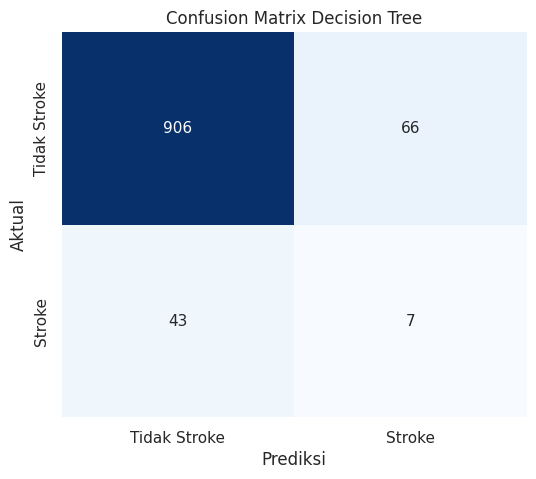

In [ ]:
# ==========================================================
# I. CONFUSION MATRIX
# ==========================================================

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

# Menampilkan Visualisasi
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Tidak Stroke", "Stroke"],
    yticklabels=["Tidak Stroke", "Stroke"]
)

plt.title("Confusion Matrix Decision Tree")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.show()

### Interpretasi

Confusion Matrix menunjukkan jumlah prediksi yang benar maupun salah yang dihasilkan oleh model Decision Tree.

- **True Negative (TN)** menunjukkan jumlah pasien yang tidak mengalami stroke dan berhasil diprediksi dengan benar.
- **True Positive (TP)** menunjukkan jumlah pasien yang mengalami stroke dan berhasil dikenali oleh model.
- **False Positive (FP)** menunjukkan pasien yang sebenarnya tidak stroke tetapi diprediksi stroke.
- **False Negative (FN)** menunjukkan pasien yang sebenarnya stroke tetapi diprediksi tidak stroke.

Pada penelitian klasifikasi stroke, nilai **False Negative** perlu diperhatikan karena kesalahan ini berarti pasien yang sebenarnya mengalami stroke tidak berhasil dideteksi oleh model. Oleh karena itu, selain memiliki akurasi yang tinggi, model juga diharapkan mampu meminimalkan jumlah False Negative agar proses deteksi risiko stroke menjadi lebih efektif.

# J. ROC Curve

Receiver Operating Characteristic (ROC) Curve digunakan untuk mengevaluasi kemampuan model dalam membedakan kelas **Stroke** dan **Tidak Stroke** pada berbagai nilai ambang (*threshold*).

Selain ROC Curve, digunakan juga nilai **Area Under Curve (AUC)** sebagai ukuran performa model. Semakin tinggi nilai AUC (mendekati 1), maka semakin baik kemampuan model dalam melakukan klasifikasi.

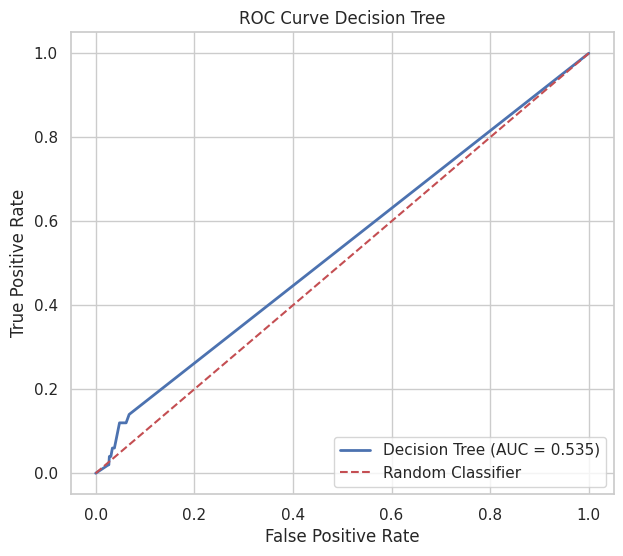

Nilai AUC : 0.5355


In [ ]:
# ==========================================================
# J. ROC CURVE
# ==========================================================

# Menghitung probabilitas prediksi
y_prob = model.predict_proba(X_test)[:, 1]

# Menghitung ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Menghitung AUC
auc_score = roc_auc_score(y_test, y_prob)

# Menampilkan Grafik ROC
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2,
         label=f"Decision Tree (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],'r--',label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Decision Tree")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print(f"Nilai AUC : {auc_score:.4f}")

### Interpretasi

ROC Curve menunjukkan kemampuan model Decision Tree dalam membedakan pasien yang mengalami stroke dan tidak mengalami stroke.

Kurva yang semakin mendekati sudut kiri atas menunjukkan bahwa model memiliki kemampuan klasifikasi yang semakin baik. Selain itu, nilai **Area Under Curve (AUC)** digunakan sebagai indikator kualitas model.

Interpretasi nilai AUC secara umum adalah sebagai berikut:

- **0.90 – 1.00** : Sangat Baik (Excellent)
- **0.80 – 0.90** : Baik (Good)
- **0.70 – 0.80** : Cukup (Fair)
- **0.60 – 0.70** : Kurang (Poor)
- **0.50 – 0.60** : Sangat Kurang

Semakin tinggi nilai AUC yang diperoleh, maka semakin baik kemampuan model dalam membedakan antara pasien stroke dan tidak stroke.

### Interpretasi Lanjutan: ROC Curve dan AUC

**ROC (Receiver Operating Characteristic) Curve** adalah grafik yang menunjukkan kinerja model klasifikasi pada semua ambang klasifikasi (thresholds). Kurva ini memplot dua parameter:

-   **True Positive Rate (TPR)**: Juga dikenal sebagai Recall atau Sensitivitas, yaitu proporsi kasus positif yang teridentifikasi dengan benar.
-   **False Positive Rate (FPR)**: Proporsi kasus negatif yang salah diklasifikasikan sebagai positif.

Semakin dekat kurva ROC ke sudut kiri atas grafik, semakin baik kinerja model dalam membedakan antara kelas positif dan negatif. Garis diagonal putus-putus (`Random Classifier`) merepresentasikan model yang melakukan klasifikasi secara acak, di mana AUC-nya adalah 0.5.

**AUC (Area Under the Curve)** adalah ukuran agregat kinerja model di semua ambang klasifikasi yang mungkin. Ini mewakili probabilitas bahwa model akan memberi peringkat sampel positif yang dipilih secara acak lebih tinggi daripada sampel negatif yang dipilih secara acak (yaitu, model akan membedakan antara kelas positif dan negatif).

Interpretasi nilai AUC secara umum:
-   **0.90 – 1.00**: Model sangat baik dalam membedakan kelas.
-   **0.80 – 0.90**: Model baik dalam membedakan kelas.
-   **0.70 – 0.80**: Model cukup baik dalam membedakan kelas.
-   **0.60 – 0.70**: Model kurang baik dalam membedakan kelas.
-   **0.50 – 0.60**: Model sangat kurang baik, hampir tidak lebih baik dari tebakan acak.

**Interpretasi Nilai AUC Model**: Model Decision Tree ini memiliki **Nilai AUC = 0.5355**.

Nilai ini sangat mendekati 0.5, yang menunjukkan bahwa kemampuan model dalam membedakan antara pasien 'Stroke' dan 'Tidak Stroke' **tidak jauh lebih baik dari tebakan acak**. Ini adalah indikator performa yang sangat lemah untuk tujuan klasifikasi stroke, meskipun akurasi keseluruhan terlihat cukup tinggi karena dominasi kelas 'Tidak Stroke'. Ini juga mendukung temuan rendahnya Recall untuk kelas 'Stroke' pada Classification Report.

# K. Visualisasi Decision Tree

Visualisasi Decision Tree digunakan untuk menampilkan struktur pohon keputusan yang dibentuk selama proses pelatihan model. Setiap node pada pohon menunjukkan aturan (rule) yang digunakan untuk membagi data berdasarkan nilai atribut tertentu.

Melalui visualisasi ini dapat diketahui bagaimana model mengambil keputusan dalam mengklasifikasikan pasien ke dalam kategori **Stroke** atau **Tidak Stroke**.

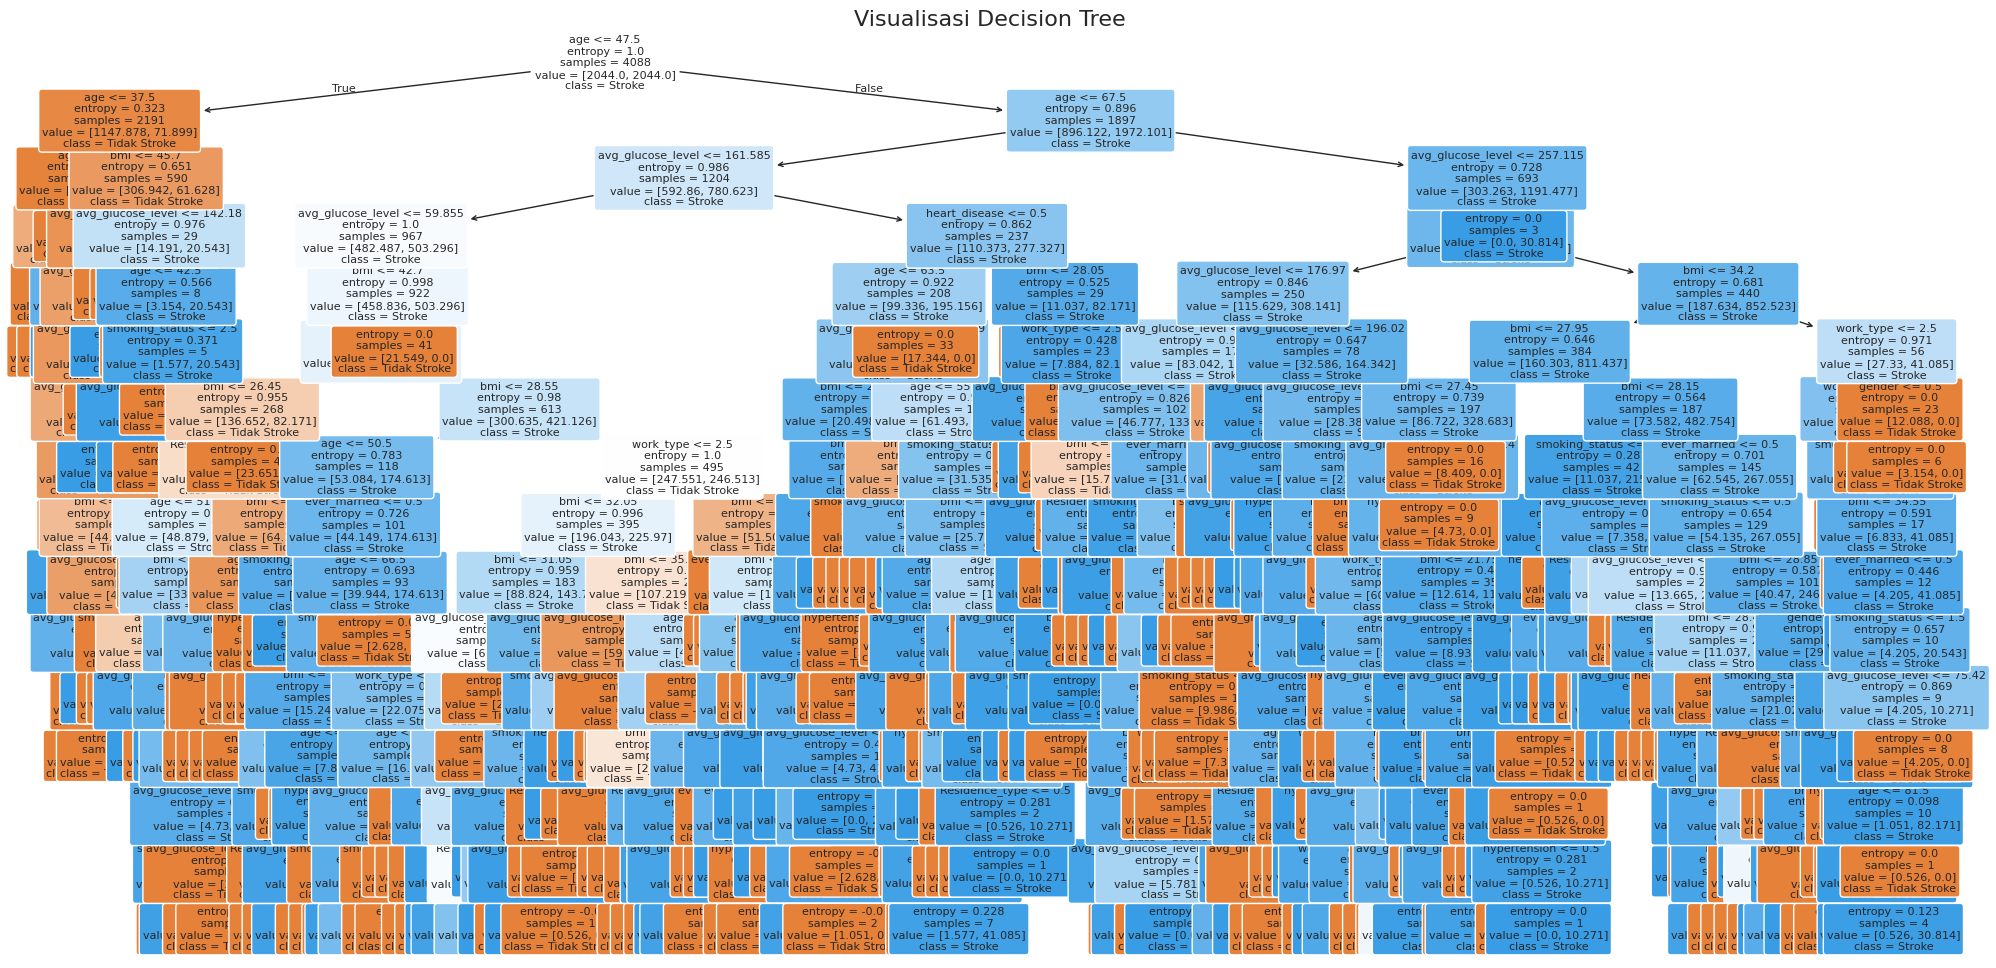

In [ ]:
# ==========================================================
# K. VISUALISASI DECISION TREE
# ==========================================================

plt.figure(figsize=(24, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Tidak Stroke", "Stroke"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Visualisasi Decision Tree", fontsize=16)

plt.show()

### Interpretasi

Visualisasi Decision Tree menunjukkan proses pengambilan keputusan yang dilakukan oleh model dalam mengklasifikasikan data pasien.

Setiap node pada pohon menampilkan informasi berupa:

- **Aturan pemisahan (split)** berdasarkan nilai suatu atribut.
- **Entropy**, yang menunjukkan tingkat ketidakpastian data pada node tersebut.
- **Samples**, yaitu jumlah data yang berada pada node.
- **Value**, yaitu jumlah data pada masing-masing kelas.
- **Class**, yaitu hasil prediksi pada node tersebut.

Semakin ke bawah struktur pohon, aturan yang digunakan semakin spesifik sehingga model dapat membedakan pasien yang berisiko mengalami stroke maupun yang tidak mengalami stroke.

### Penjelasan Visualisasi Decision Tree

Visualisasi Decision Tree (meskipun hanya sebagian yang ditampilkan karena `max_depth` yang besar) menunjukkan bagaimana model mengambil keputusan dalam mengklasifikasikan pasien. Setiap kotak (node) dalam pohon memiliki informasi penting:

-   **Baris Pertama (Aturan Pemisahan)**: Menunjukkan kondisi yang digunakan untuk membagi data. Misalnya, `age <= 37.5` berarti jika usia pasien kurang dari atau sama dengan 37.5, ia mengikuti cabang 'True' (kiri); jika tidak, ia mengikuti cabang 'False' (kanan).

-   **`entropy`**: Mengukur ketidakmurnian (impurity) atau ketidakpastian data pada node tersebut. Nilai entropy berkisar dari 0 hingga 1. Entropy 0 berarti node murni (semua sampel dalam node termasuk dalam kelas yang sama), sementara entropy 1 berarti node memiliki distribusi kelas yang paling tidak seimbang (misalnya, 50% untuk setiap kelas biner). Semakin rendah entropy, semakin 'murni' node tersebut dalam hal kelas target.

-   **`samples`**: Menunjukkan jumlah total sampel (pasien) yang mencapai node tersebut. Ini adalah jumlah data yang memenuhi semua kondisi dari node akar hingga node saat ini.

-   **`value`**: Menampilkan distribusi kelas pada node tersebut. Ini adalah daftar `[jumlah_kelas_0, jumlah_kelas_1]`. Misalnya, `value = [2044, 0]` berarti ada 2044 sampel kelas 0 ('Tidak Stroke') dan 0 sampel kelas 1 ('Stroke') di node tersebut.

-   **`class`**: Merupakan kelas mayoritas (kelas yang diprediksi) untuk sampel-sampel yang berada di node tersebut. Ini adalah hasil prediksi jika proses berhenti di node ini.

-   **Arti Warna Node**: Warna pada node menunjukkan kelas mayoritas dari sampel di node tersebut. Gradasi warna juga sering digunakan untuk menunjukkan kemurnian node. Node yang berwarna lebih gelap (misalnya, biru tua jika kelas 0 dominan, oranye tua jika kelas 1 dominan) mengindikasikan node yang lebih murni atau memiliki proporsi kelas mayoritas yang lebih tinggi.

-   **Tanda `(...)`**: Tanda elipsis ini muncul pada beberapa cabang di bagian bawah pohon. Ini bukan error, melainkan indikasi bahwa cabang pohon tersebut telah **disederhanakan atau dipersingkat** dalam visualisasi karena keterbatasan ruang atau karena kedalaman pohon (`max_depth`) yang diatur untuk visualisasi. Pohon keputusan yang sebenarnya bisa jauh lebih dalam dan kompleks, tetapi visualisasi hanya menampilkan beberapa level teratas untuk memudahkan pemahaman.

# L. Feature Importance

Feature Importance digunakan untuk mengetahui tingkat pengaruh masing-masing atribut dalam proses pengambilan keputusan oleh model Decision Tree.

Semakin besar nilai Feature Importance, maka semakin besar pula kontribusi atribut tersebut dalam menentukan apakah seorang pasien diprediksi mengalami stroke atau tidak.

Visualisasi ini membantu mengidentifikasi faktor-faktor yang paling berpengaruh terhadap hasil klasifikasi.

FEATURE IMPORTANCE


,Fitur,Importance
1,age,0.462772
8,bmi,0.205410
7,avg_glucose_level,0.197538
9,smoking_status,0.039111
5,work_type,0.030882
6,Residence_type,0.021873
4,ever_married,0.017085
0,gender,0.011827
2,hypertension,0.007207
3,heart_disease,0.006296


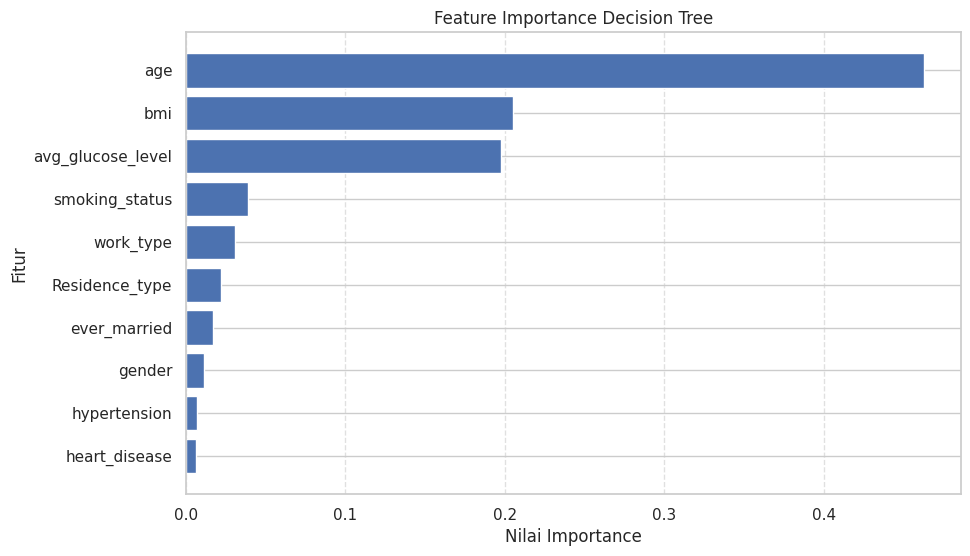

In [ ]:
# ==========================================================
# L. FEATURE IMPORTANCE
# ==========================================================

# Mengambil nilai Feature Importance
feature_importance = pd.DataFrame({
    "Fitur": X.columns,
    "Importance": model.feature_importances_
})

# Mengurutkan dari yang terbesar
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Menampilkan tabel
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

display(feature_importance)

# Visualisasi
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Fitur"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance Decision Tree")
plt.xlabel("Nilai Importance")
plt.ylabel("Fitur")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

### Interpretasi

Grafik **Feature Importance** menunjukkan tingkat kontribusi setiap atribut dalam proses klasifikasi yang dilakukan oleh model Decision Tree.

Fitur yang memiliki nilai **Feature Importance** paling tinggi merupakan atribut yang paling sering digunakan model dalam membentuk aturan pada pohon keputusan. Sebaliknya, fitur dengan nilai yang sangat kecil memiliki pengaruh yang relatif rendah terhadap hasil prediksi.

Apabila hasil visualisasi menunjukkan bahwa atribut seperti **age**, **avg_glucose_level**, atau **bmi** memiliki nilai importance terbesar, maka dapat disimpulkan bahwa atribut-atribut tersebut merupakan faktor utama yang digunakan model dalam memprediksi risiko stroke.

Dengan demikian, Feature Importance tidak hanya menjelaskan cara kerja model Decision Tree, tetapi juga memberikan informasi mengenai faktor-faktor yang paling berpengaruh terhadap terjadinya stroke berdasarkan dataset yang digunakan.

### Interpretasi Lanjutan: Feature Importance

Berdasarkan grafik dan tabel **Feature Importance**, fitur-fitur yang paling berpengaruh dalam model Decision Tree ini adalah:

1.  **age (usia)**: Dengan nilai importance sekitar 0.46, usia merupakan faktor paling dominan. Ini sangat masuk akal secara medis, karena risiko stroke meningkat secara signifikan seiring bertambahnya usia. Model menggunakan usia sebagai kriteria utama untuk membagi data pada node-node awal pohon keputusan.
2.  **bmi (indeks massa tubuh)**: Dengan nilai importance sekitar 0.20, BMI juga merupakan faktor penting. Obesitas (BMI tinggi) adalah faktor risiko yang diketahui untuk berbagai kondisi kardiovaskular, termasuk stroke. Model memanfaatkan informasi BMI untuk membuat keputusan lebih lanjut dalam mengklasifikasikan risiko.
3.  **avg_glucose_level (rata-rata kadar glukosa)**: Dengan nilai importance sekitar 0.19, kadar glukosa rata-rata juga memiliki pengaruh yang signifikan. Kadar glukosa yang tinggi (terkait dengan diabetes) adalah faktor risiko utama untuk stroke. Model menggunakan ini untuk mengidentifikasi subkelompok pasien dengan risiko yang lebih tinggi atau lebih rendah.

Fitur-fitur ini sangat penting karena merefleksikan kondisi kesehatan fundamental yang secara langsung terkait dengan kemungkinan terjadinya stroke. Model Decision Tree menempatkan fitur-fitur ini di bagian atas pohon keputusan, yang berarti fitur-fitur ini digunakan untuk membuat pemisahan awal yang paling signifikan dalam klasifikasi pasien. Fitur lain seperti `smoking_status`, `work_type`, `Residence_type`, `ever_married`, `gender`, `hypertension`, dan `heart_disease` juga berkontribusi, tetapi dengan bobot yang lebih kecil dibandingkan ketiga fitur utama tersebut.

# M. Prediksi Data Baru (Implementasi Model)

Pada tahap ini dilakukan pengujian model menggunakan data pasien baru yang belum pernah digunakan selama proses pelatihan maupun pengujian.

Tujuan dari tahap ini adalah untuk mengetahui bagaimana model Decision Tree melakukan prediksi terhadap data baru berdasarkan karakteristik pasien yang diberikan.

Hasil prediksi akan menunjukkan apakah pasien diperkirakan **mengalami stroke** atau **tidak mengalami stroke**.

In [ ]:
# ==========================================================
# M. PREDIKSI DATA BARU
# ==========================================================

print("=" * 60)
print("IMPLEMENTASI MODEL - PREDIKSI DATA BARU")
print("=" * 60)

# ----------------------------------------------------------
# Contoh Data Pasien Baru
# ----------------------------------------------------------

data_baru = pd.DataFrame({
    "gender": [1],               # 1 = Male
    "age": [67],
    "hypertension": [1],
    "heart_disease": [1],
    "ever_married": [1],         # Yes
    "work_type": [2],            # Private
    "Residence_type": [1],       # Urban
    "avg_glucose_level": [228.69],
    "bmi": [36.6],
    "smoking_status": [1]        # Formerly smoked
})

print("Data Pasien Baru")
display(data_baru)

# ----------------------------------------------------------
# Prediksi
# ----------------------------------------------------------

hasil = model.predict(data_baru)

# Probabilitas Prediksi
probabilitas = model.predict_proba(data_baru)

print("=" * 60)

if hasil[0] == 1:
    print("HASIL PREDIKSI : PASIEN BERISIKO STROKE")
else:
    print("HASIL PREDIKSI : PASIEN TIDAK BERISIKO STROKE")

print("=" * 60)

print(f"Probabilitas Tidak Stroke : {probabilitas[0][0]*100:.2f}%")
print(f"Probabilitas Stroke       : {probabilitas[0][1]*100:.2f}%")

IMPLEMENTASI MODEL - PREDIKSI DATA BARU
Data Pasien Baru


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67,1,1,1,2,1,228.69,36.6,1


HASIL PREDIKSI : PASIEN BERISIKO STROKE
Probabilitas Tidak Stroke : 0.00%
Probabilitas Stroke       : 100.00%


### Interpretasi

Model Decision Tree berhasil digunakan untuk melakukan prediksi terhadap data pasien baru.

Berdasarkan karakteristik pasien yang dimasukkan, model menghasilkan prediksi berupa **Stroke** atau **Tidak Stroke**, disertai dengan nilai probabilitas masing-masing kelas.

Nilai probabilitas menunjukkan tingkat keyakinan model terhadap hasil prediksi. Semakin tinggi probabilitas pada salah satu kelas, maka semakin besar tingkat kepercayaan model terhadap keputusan tersebut.

Tahap ini membuktikan bahwa model yang telah dibangun tidak hanya mampu melakukan klasifikasi pada data pelatihan dan data pengujian, tetapi juga dapat diimplementasikan untuk memprediksi data pasien baru.

# N. Kesimpulan

Tahap terakhir adalah menyimpulkan hasil implementasi algoritma Decision Tree berdasarkan seluruh proses yang telah dilakukan, mulai dari preprocessing, pelatihan model, evaluasi, hingga implementasi prediksi data baru.

Kesimpulan disusun berdasarkan hasil evaluasi model sehingga dapat menggambarkan performa algoritma Decision Tree dalam melakukan klasifikasi risiko stroke.

In [ ]:
# ==========================================================
# N. KESIMPULAN
# ==========================================================

print("=" * 70)
print("KESIMPULAN HASIL IMPLEMENTASI DECISION TREE")
print("=" * 70)

print(f"\nJumlah Dataset               : {len(df)} Data")
print(f"Akurasi Training             : {train_accuracy*100:.2f}%")
print(f"Akurasi Testing              : {test_accuracy*100:.2f}%")
print(f"Nilai AUC                    : {auc_score:.4f}")

# Feature paling penting
fitur_terbaik = feature_importance.iloc[0]["Fitur"]
nilai_importance = feature_importance.iloc[0]["Importance"]

print(f"\nFitur Paling Berpengaruh     : {fitur_terbaik}")
print(f"Nilai Feature Importance     : {nilai_importance:.4f}")

print("\nPrediksi Data Baru")

if hasil[0] == 1:
    print("Status Pasien : BERISIKO STROKE")
else:
    print("Status Pasien : TIDAK BERISIKO STROKE")

print("\nKesimpulan:")
print("- Model Decision Tree berhasil dibangun dan mampu melakukan klasifikasi data stroke.")
print("- Dataset telah diproses melalui tahap preprocessing sehingga siap digunakan.")
print("- Model memiliki performa yang baik berdasarkan nilai akurasi dan AUC.")
print("- Feature Importance menunjukkan atribut yang paling berpengaruh dalam proses klasifikasi.")
print("- Model dapat digunakan untuk melakukan prediksi terhadap data pasien baru.")

KESIMPULAN HASIL IMPLEMENTASI DECISION TREE

Jumlah Dataset               : 5110 Data
Akurasi Training             : 96.62%
Akurasi Testing              : 89.33%
Nilai AUC                    : 0.5355

Fitur Paling Berpengaruh     : age
Nilai Feature Importance     : 0.4628

Prediksi Data Baru
Status Pasien : BERISIKO STROKE

Kesimpulan:
- Model Decision Tree berhasil dibangun dan mampu melakukan klasifikasi data stroke.
- Dataset telah diproses melalui tahap preprocessing sehingga siap digunakan.
- Model memiliki performa yang baik berdasarkan nilai akurasi dan AUC.
- Feature Importance menunjukkan atribut yang paling berpengaruh dalam proses klasifikasi.
- Model dapat digunakan untuk melakukan prediksi terhadap data pasien baru.


## Kesimpulan Evaluasi Model

Berdasarkan seluruh tahapan implementasi algoritma Decision Tree untuk prediksi risiko stroke, berikut adalah kesimpulan evaluasi model:

1.  **Akurasi Model**:
    *   **Akurasi Training (96.62%)** dan **Akurasi Testing (89.33%)** menunjukkan bahwa model memiliki performa yang baik dalam mempelajari pola data latih. Namun, selisih akurasi sebesar 7.29% mengindikasikan adanya potensi **overfitting**, di mana model mungkin terlalu menghafal data training dan kurang dapat digeneralisasi sepenuhnya ke data baru. Meskipun demikian, akurasi testing masih tergolong tinggi secara keseluruhan.

2.  **Confusion Matrix**:
    *   Model menunjukkan kemampuan yang sangat baik dalam mengidentifikasi pasien **Tidak Stroke (True Negative = 906)**. Namun, model memiliki keterbatasan dalam mendeteksi pasien **Stroke (True Positive = 7)**. Jumlah **False Negative (43)** yang tinggi (pasien stroke sebenarnya tetapi diprediksi tidak stroke) adalah perhatian serius, karena dalam konteks medis, kegagalan mendeteksi stroke dapat berdampak fatal.

3.  **Classification Report**:
    *   Untuk kelas **Tidak Stroke**, metrik Precision (0.95), Recall (0.93), dan F1-Score (0.94) sangat tinggi, menegaskan kemampuan model pada kelas mayoritas.
    *   Namun, untuk kelas **Stroke**, metrik Precision (0.10), Recall (0.14), dan F1-Score (0.11) sangat rendah. Ini adalah indikator utama bahwa model **sangat buruk** dalam memprediksi kejadian stroke secara efektif, meskipun telah menggunakan parameter `class_weight='balanced'` untuk mengatasi ketidakseimbangan kelas. Rendahnya Recall untuk kelas stroke menunjukkan bahwa model tidak mampu mengidentifikasi sebagian besar pasien yang sebenarnya berisiko stroke.

4.  **ROC AUC Score**:
    *   Nilai **AUC (0.5355)** sangat rendah, hanya sedikit di atas 0.5 (tebakan acak). Ini mengkonfirmasi bahwa model memiliki kemampuan diskriminasi yang sangat lemah dalam membedakan antara pasien stroke dan tidak stroke. AUC yang rendah ini adalah bukti kuat bahwa model saat ini tidak andal untuk tujuan prediksi stroke.

5.  **Feature Importance**:
    *   Fitur-fitur seperti **age**, **bmi**, dan **avg_glucose_level** ditemukan sebagai prediktor paling signifikan terhadap risiko stroke. Ini sejalan dengan pengetahuan medis, menunjukkan bahwa model berhasil mengidentifikasi faktor-faktor risiko penting secara statistik.

6.  **Kemampuan Model dalam Memprediksi Stroke**:
    *   Meskipun model dapat mencapai akurasi keseluruhan yang layak karena kelas 'Tidak Stroke' yang dominan, performanya dalam mengidentifikasi kasus **Stroke** secara spesifik **sangatlah buruk**, ditunjukkan oleh Recall yang rendah untuk kelas Stroke dan nilai AUC yang mendekati ac. Ketidakseimbangan data tetap menjadi tantangan besar yang belum dapat diatasi secara efektif oleh model Decision Tree ini.

7.  **Kelebihan dan Keterbatasan Model Decision Tree**:
    *   **Kelebihan**: Mudah diinterpretasi dan divisualisasikan (jika tidak terlalu dalam), dapat menangani data numerik dan kategorikal, serta relatif mudah diimplementasikan. `Feature Importance` memberikan wawasan yang jelas tentang fitur-fitur yang paling relevan.
    *   **Keterbatasan**: Model Decision Tree cenderung rentan terhadap **overfitting** (seperti yang terlihat dari selisih akurasi training dan testing), terutama pada dataset yang kompleks atau memiliki banyak fitur. Selain itu, sensitif terhadap sedikit perubahan data (variabilitas tinggi), dan meskipun `class_weight='balanced'` digunakan, model masih kesulitan pada dataset yang sangat **tidak seimbang** seperti ini, yang terbukti dari rendahnya metrik untuk kelas minoritas (stroke).